=== Decision Tree Report ===
              precision    recall  f1-score   support

          No       0.62      0.76      0.68      1116
         Yes       0.90      0.83      0.86      3033

    accuracy                           0.81      4149
   macro avg       0.76      0.79      0.77      4149
weighted avg       0.83      0.81      0.82      4149



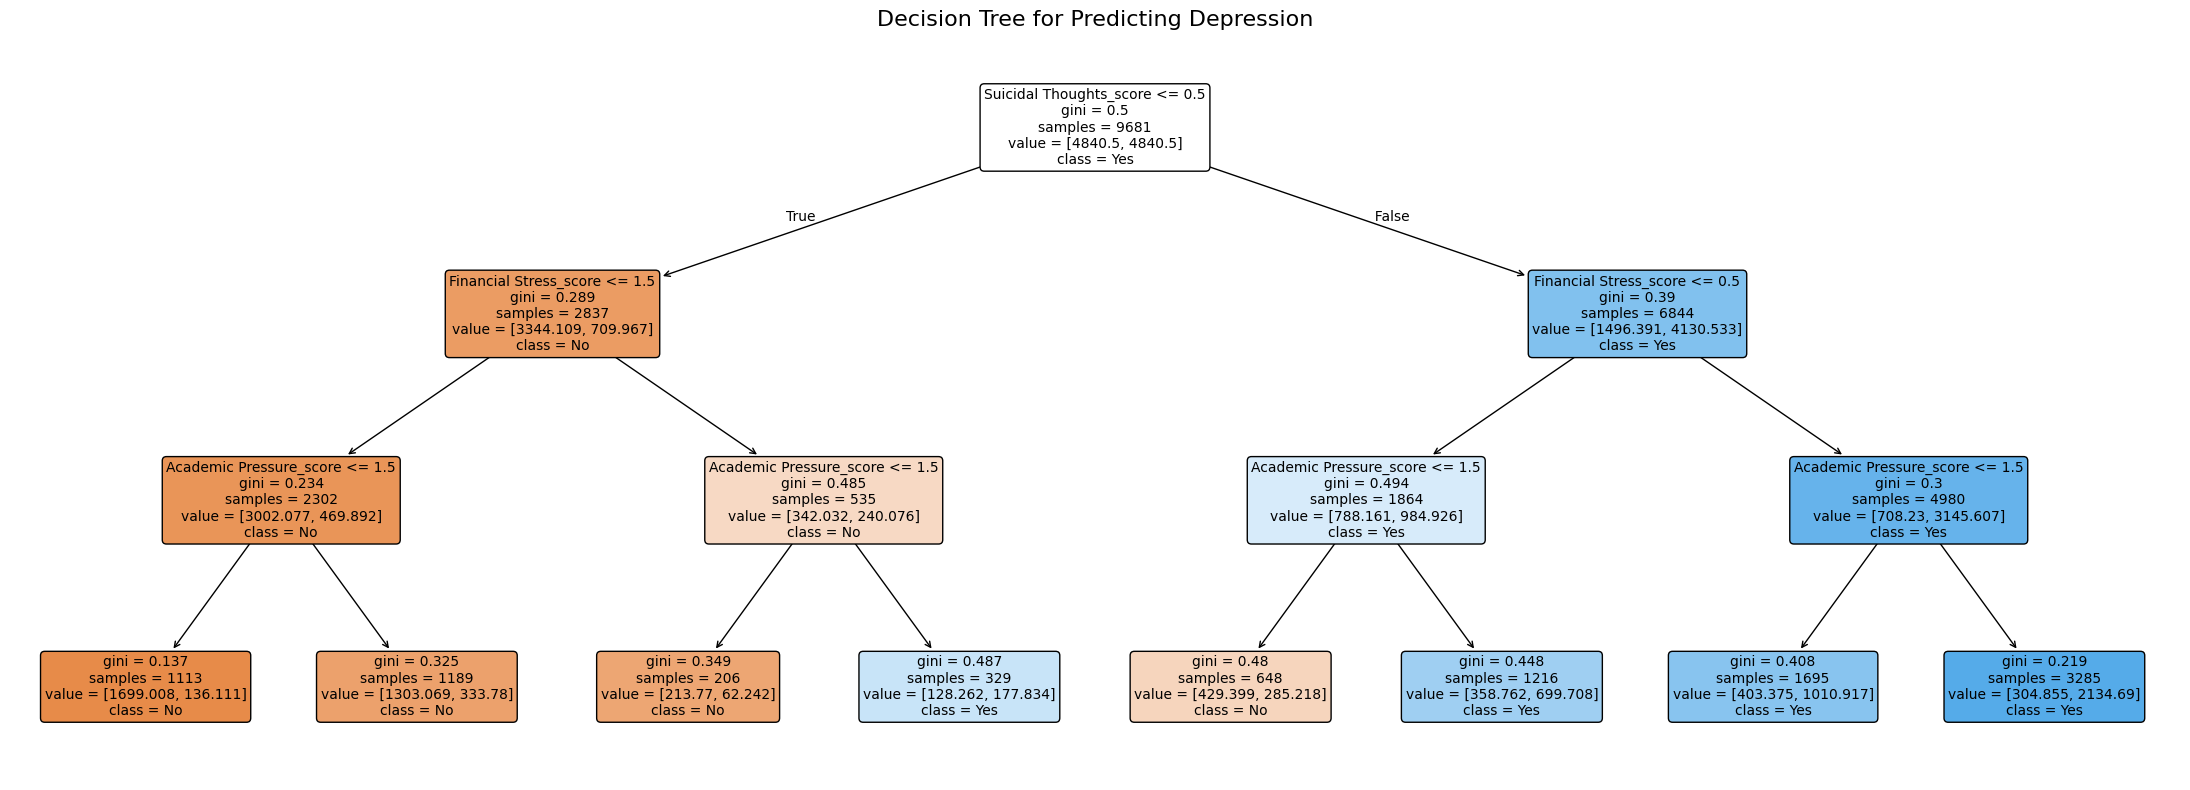

=== Decision Tree Report ===
              precision    recall  f1-score   support

           0       0.62      0.76      0.68      1116
           1       0.90      0.83      0.86      3033

    accuracy                           0.81      4149
   macro avg       0.76      0.79      0.77      4149
weighted avg       0.83      0.81      0.82      4149



In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_excel("preprocessed_depression.csv.xlsx")
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]  # Remove unnamed columns

# Define score mappings for all categorical variables
score_maps = {
    'CGPA (categorical)': {"Low": 0, "Average": 1, "High": 2},
    'Academic Pressure': {"Low": 0, "Moderate": 1, "High": 2},
    'Study Satisfaction': {"Low": 0, "Moderate": 1, "High": 2},
    'Sleep Duration': {"Very short": 0, "Short": 1, "7-8 hours": 2, "Long": 3},
    'Dietary Habits': {"Unhealthy": 0, "Moderate": 1, "Healthy": 2},
    'Suicidal Thoughts': {"Yes": 1, "No": 0},
    'Work Study Hours': {"Low": 0, "Moderate": 1, "High": 2},
    'Financial Stress': {"Low": 0, "Moderate": 1, "High": 2},
    'Family History': {"Yes": 1, "No": 0}
}

# Apply scoring to new columns
for col, mapping in score_maps.items():
    df[col + "_score"] = df[col].map(mapping)

# Drop rows with any NaN values in features or Depression label
required_cols = [col + "_score" for col in score_maps] + ['Depression']
df = df.dropna(subset=required_cols)

# Define feature matrix and target vector
X = df[[col + "_score" for col in score_maps]]
y = df["Depression"]

# Encode target (0 = No, 1 = Yes)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# === Decision Tree ===
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight="balanced")
tree_clf.fit(X_train, y_train)
tree_preds = tree_clf.predict(X_test)

print("=== Decision Tree Report ===")
print(classification_report(y_test, tree_preds, target_names=["No", "Yes"]))

# Fix: Ensure plot shows correctly
plt.figure(figsize=(22, 8))
plot_tree(tree_clf,
          feature_names=X.columns,
          class_names=["No", "Yes"],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree for Predicting Depression", fontsize=16)
plt.tight_layout()
plt.show()

print("=== Decision Tree Report ===")
print(classification_report(y_test, tree_preds, target_names=label_encoder.classes_.astype(str)))

